### Import Libraries

In [61]:
# Import Libraries
import os                                                              # handle file paths
import numpy as np                                                     # numerical operations
import matplotlib.pyplot as plt                                        # graphs

import tensorflow as tf                                                # deep learning
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models

### Dataset Paths

In [62]:
train_dir = "train"
val_dir = "valid"
test_dir = "test"

### Data Preprocessing & Augmentation

In [63]:
train_datagen = ImageDataGenerator(
    rescale=1./255,          # normalize pixel 0 -1
    rotation_range=20,       # rotating image
    zoom_range=0.2,          # zoom
    horizontal_flip=True     # flip image
)

val_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

### Load Dataset

In [64]:
train_data = train_datagen.flow_from_directory(
    train_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary'
)

val_data = val_datagen.flow_from_directory(
    val_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary'
)

test_data = test_datagen.flow_from_directory(
    test_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary',
    shuffle=False
)

Found 2662 images belonging to 2 classes.
Found 442 images belonging to 2 classes.
Found 215 images belonging to 2 classes.


Explanation:
- Here it will automatically read images from folder and resize it in 224, 224 
- shuffle=False (required for correct evaluation)

### Check Class Labels

In [65]:
print(train_data.class_indices)

{'bird': 0, 'drone': 1}


### Build Custom CNN (Convolutional Neural Network)

In [66]:
cnn_model = models.Sequential()

cnn_model.add(layers.Conv2D(32, (3,3), activation='relu', input_shape=(224,224,3)))    # detect simple features
cnn_model.add(layers.MaxPooling2D(2,2))

cnn_model.add(layers.Conv2D(64, (3,3), activation='relu'))                             # detect shapes 
cnn_model.add(layers.MaxPooling2D(2,2))

cnn_model.add(layers.Conv2D(128, (3,3), activation='relu'))                            # detect full object
cnn_model.add(layers.MaxPooling2D(2,2))

cnn_model.add(layers.Flatten())                                                        # make final decison 
cnn_model.add(layers.Dense(128, activation='relu'))
cnn_model.add(layers.Dropout(0.5))
cnn_model.add(layers.Dense(1, activation='sigmoid'))

c:\Users\updes\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Explanation
- Basically it detect edges, shapes and complex objects 
- we use "Sequential model" so Layers will be added one after another in order
- we apply 32 filter, each filter size 3×3, and convert input image size into 224*224 with 3 channel(RGB)
- it will detect edge,lines and texture
- MaxPooling2D(2,2)   :- it will help us to reduce size of image and speed up learning
- Flatten()           :- it need in Dense layering which help us to convert 2D maps into 1D vector
- layers.Dense(128)   :- it will act like decision making layer
- layers.Dropout(0.5) :- it will reduce load during it will turn off 50% work during traning model

##### layers.Dense(1, activation='sigmoid') :
         - Output = 1 value between 0 and 1
         - closer to 0 → Bird
         - closer to 1 → Drone


### Compile Model

In [67]:
cnn_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

Explanation
- we use Adam Optimizer for fast convergence
- binary_crossentropy → for 2 classes

### Train Model

In [68]:
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True
)

history = cnn_model.fit(
    train_data,
    validation_data=val_data,
    epochs=10,
    callbacks=[early_stop]
)

Epoch 1/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 65s 740ms/step - accuracy: 0.6037 - loss: 0.7409 - val_accuracy: 0.7172 - val_loss: 0.5518
Epoch 2/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 61s 729ms/step - accuracy: 0.7284 - loss: 0.5512 - val_accuracy: 0.7443 - val_loss: 0.5113
Epoch 3/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 56s 666ms/step - accuracy: 0.7573 - loss: 0.4971 - val_accuracy: 0.7715 - val_loss: 0.4769
Epoch 4/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 54s 646ms/step - accuracy: 0.8043 - loss: 0.4234 - val_accuracy: 0.7964 - val_loss: 0.4627
Epoch 5/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 55s 655ms/step - accuracy: 0.8095 - loss: 0.4160 - val_accuracy: 0.7783 - val_loss: 0.4444
Epoch 6/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 56s 666ms/step - accuracy: 0.8103 - loss: 0.4108 - val_accuracy: 0.8281 - val_loss: 0.4227
Epoch 7/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 56s 665ms/step - accuracy: 0.8242 - loss: 0.3856 - val_accuracy: 0.8054 - val_loss: 0.4465
Epoch 8/10
84/84 ━━━━━━━━━━━━━━━━━━━━ 57s 680ms/step - accuracy: 0.8479 - loss: 0.3516 - val_accu

Explanation
- Stops training when model stops improve

### Plot Performance

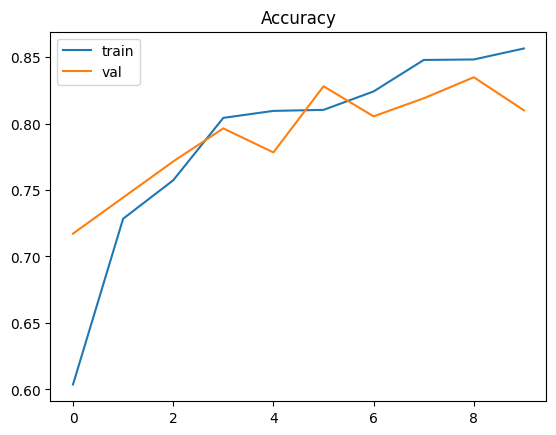

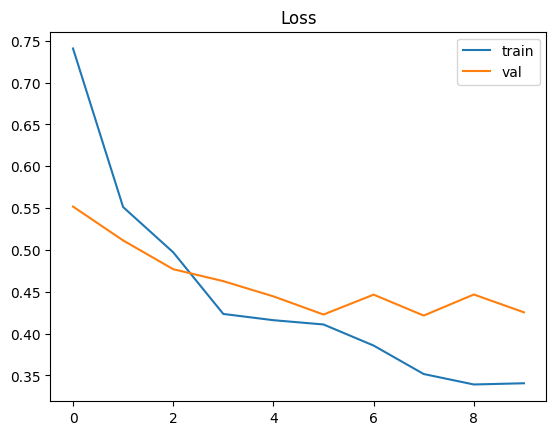

In [69]:
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.legend(['train', 'val'])
plt.title("Accuracy")
plt.show()

plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.legend(['train', 'val'])
plt.title("Loss")
plt.show()

### Evaluate Model

In [70]:
test_loss, test_acc = cnn_model.evaluate(test_data)
print("Test Accuracy:", test_acc)

7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 178ms/step - accuracy: 0.8698 - loss: 0.3356
Test Accuracy: 0.869767427444458


### Confusion Matrix

In [71]:
from sklearn.metrics import confusion_matrix, classification_report

preds = cnn_model.predict(test_data)
pred_labels = (preds > 0.5).astype(int)

print(confusion_matrix(test_data.classes, pred_labels))
print(classification_report(test_data.classes, pred_labels))

7/7 ━━━━━━━━━━━━━━━━━━━━ 1s 183ms/step
[[106  15]
 [ 13  81]]
              precision    recall  f1-score   support

           0       0.89      0.88      0.88       121
           1       0.84      0.86      0.85        94

    accuracy                           0.87       215
   macro avg       0.87      0.87      0.87       215
weighted avg       0.87      0.87      0.87       215



### Save Model

In [72]:
cnn_model.save("cnn_model.h5")

### Transfer Learning

In [73]:
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(224,224,3),
    include_top=False,
    weights='imagenet'
)

base_model.trainable = False

x = base_model.output
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(0.5)(x)
output = layers.Dense(1, activation='sigmoid')(x)

model_tl = models.Model(inputs=base_model.input, outputs=output)

### Compile & Train Transfer Model

In [74]:
model_tl.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

history_tl = model_tl.fit(
    train_data,
    validation_data=val_data,
    epochs=5
)

Epoch 1/5
84/84 ━━━━━━━━━━━━━━━━━━━━ 68s 751ms/step - accuracy: 0.9294 - loss: 0.1802 - val_accuracy: 0.9729 - val_loss: 0.0905
Epoch 2/5
84/84 ━━━━━━━━━━━━━━━━━━━━ 61s 725ms/step - accuracy: 0.9677 - loss: 0.0849 - val_accuracy: 0.9729 - val_loss: 0.0837
Epoch 3/5
84/84 ━━━━━━━━━━━━━━━━━━━━ 61s 721ms/step - accuracy: 0.9775 - loss: 0.0665 - val_accuracy: 0.9683 - val_loss: 0.0849
Epoch 4/5
84/84 ━━━━━━━━━━━━━━━━━━━━ 62s 735ms/step - accuracy: 0.9745 - loss: 0.0662 - val_accuracy: 0.9615 - val_loss: 0.1109
Epoch 5/5
84/84 ━━━━━━━━━━━━━━━━━━━━ 62s 743ms/step - accuracy: 0.9767 - loss: 0.0558 - val_accuracy: 0.9638 - val_loss: 0.0879


### Save Best Model

In [79]:

model_tl.save("final_model.h5")
print("Model saved successfully")

Model saved successfully


### Predict on New Image

In [80]:
from tensorflow.keras.preprocessing import image

import os

img_path = "test/bird/" + os.listdir("test/bird")[0]

img = image.load_img(img_path, target_size=(224,224))
img_array = image.img_to_array(img) / 255.0
img_array = np.expand_dims(img_array, axis=0)

prediction = model_tl.predict(img_array)

if prediction[0][0] > 0.5:
    print("Drone")
else:
    print("Bird")

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
Drone


### Streamlit App

In [82]:
import streamlit as st
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image
import numpy as np

model = load_model("final_model.h5")

st.title("Bird vs Drone Classifier")

uploaded_file = st.file_uploader("Upload an image", type=["jpg", "png", "jpeg"])

if uploaded_file is not None:
    img = image.load_img(uploaded_file, target_size=(224,224))
    st.image(img, caption="Uploaded Image")

    img_array = image.img_to_array(img) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    pred = model.predict(img_array)

    if pred[0][0] > 0.5:
        st.success("Drone Detected")
    else:
        st.success("Bird Detected")

2026-04-16 15:42:57.002 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-16 15:42:57.003 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-16 15:42:57.003 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-16 15:42:57.004 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-16 15:42:57.007 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-16 15:42:57.008 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-16 15:42:57.010 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-04-16 15:42:57.011 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bar